# Homework

## Problem 1

Let $f(x) = 2\sin x - \cos{2x}$. Write a function `beauty_derivative_plot` that takes a point $x$ and plots the function $f(x)$ and its derivative $f'(x)$ in the range $x \in [-2\pi, 2\pi]$. The function should also plot the tangent line to the function at the point $x$. 

Example of output for $x = -3, -2, 1.7$:

```python
beauty_derivative_plot(-3)
```
<img src="https://i.ibb.co/zTdYLC0J/tangent-line-3-0.png" width="600"/>

```python
beauty_derivative_plot(-2)
```
<img src="https://i.ibb.co/hFXNZ7wS/tangent-line-2-0.png" width="600"/>

```python
beauty_derivative_plot(1.7)
```
<img src="https://i.ibb.co/217yHstn/tangent-line-1-7.png" width="600"/>

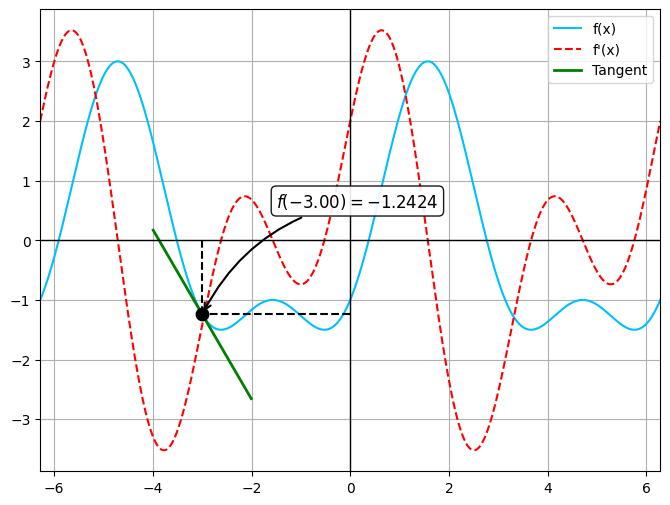

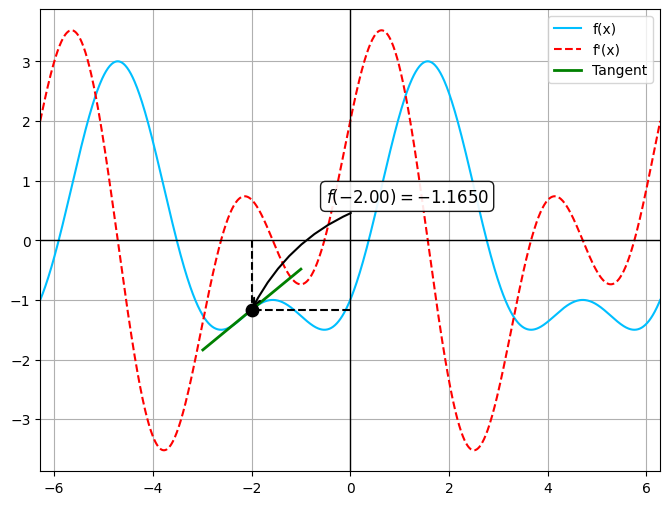

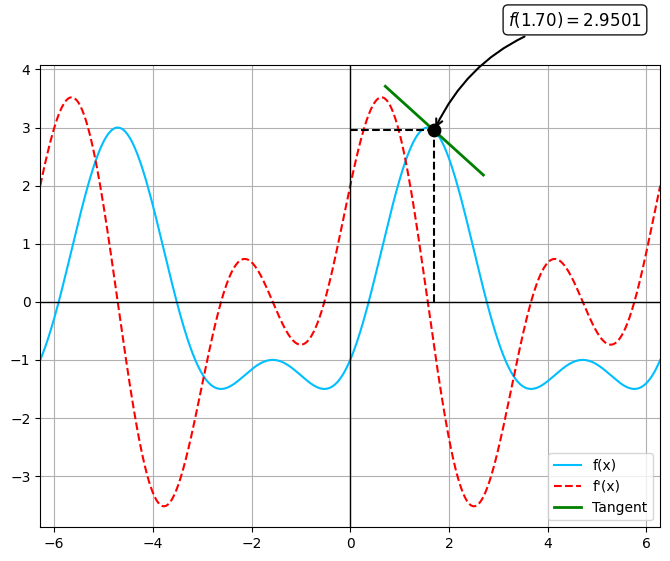

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def beauty_derivative_plot(x0):
    # функция и производная
    f = lambda x: 2*np.sin(x) - np.cos(2*x)
    df = lambda x: 2*np.cos(x) + 2*np.sin(2*x)

    # диапазон
    x = np.linspace(-2*np.pi, 2*np.pi, 1000)

    # значение в точке
    y0 = f(x0)
    slope = df(x0)

    # касательная
    tangent = y0 + slope*(x - x0)

    # создаем график
    plt.figure(figsize=(8,6))

    # сама функция — голубая
    plt.plot(x, f(x), color="deepskyblue", label="f(x)")

    # производная — красная пунктирная
    plt.plot(x, df(x), "r--", label="f'(x)")

    # касательная — зелёная (небольшой кусок)
    mask = np.abs(x - x0) < 1
    plt.plot(x[mask], tangent[mask], color="green", linewidth=2, label="Tangent")

    # точка касания — чёрная жирная
    plt.scatter(x0, y0, color="black", s=80, zorder=5)

    # подпись со стрелкой
    plt.annotate(
    r"$f({:.2f}) = {:.4f}$".format(x0, y0),
    xy=(x0, y0),                     # точка касания
    xytext=(x0 + 1.5, y0 + 1.8),      # положение подписи
    arrowprops=dict(
        arrowstyle="->",
        color="black",
        linewidth=1.5,
        connectionstyle="arc3,rad=0.25"  # ← вот изгиб стрелки
    ),
    fontsize=12,
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white",
        ec="black",
        alpha=0.9
    )
)
    
    # пунктирные перпендикуляры к осям
    plt.plot([x0, x0], [0, y0], "k--")
    plt.plot([0, x0], [y0, y0], "k--")

    plt.axhline(0, color="black", linewidth=1)
    plt.axvline(0, color="black", linewidth=1)

    plt.xlim(-2*np.pi, 2*np.pi)
    plt.legend()
    plt.grid(True)
    plt.show()
    
beauty_derivative_plot(-3)
beauty_derivative_plot(-2)
beauty_derivative_plot(1.7)

## Problem 2

The data in [populations.txt](http://www.scipy-lectures.org/_downloads/populations.txt) describes the populations of hares, lynxes and carrots in northern Canada during 20 years. Get the data with 
```python
np.loadtxt('http://www.scipy-lectures.org/_downloads/populations.txt')
```
and do the following exercises **without for-loops (!!!)**.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("dataset/populations.txt")

years = data[:, 0]
hares = data[:, 1]
lynxes = data[:, 2]
carrots = data[:, 3]

- Plot the population size of each species for each year on a single graph. Add legend and axis labels to the plot.

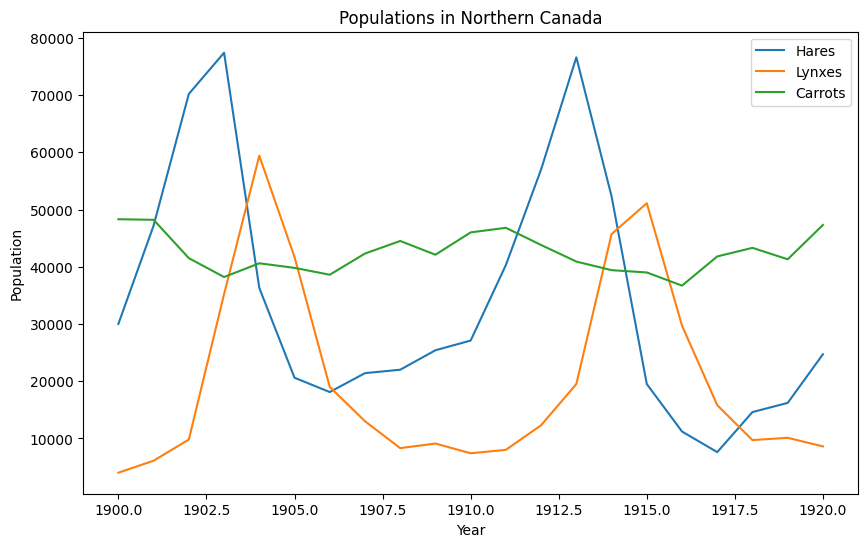

In [4]:
plt.figure(figsize=(10,6))

plt.plot(years, hares, label="Hares")
plt.plot(years, lynxes, label="Lynxes")
plt.plot(years, carrots, label="Carrots")

plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.title("Populations in Northern Canada")
plt.show()

- Find which year each species had the largest population. Mark these years in the plot of populations.

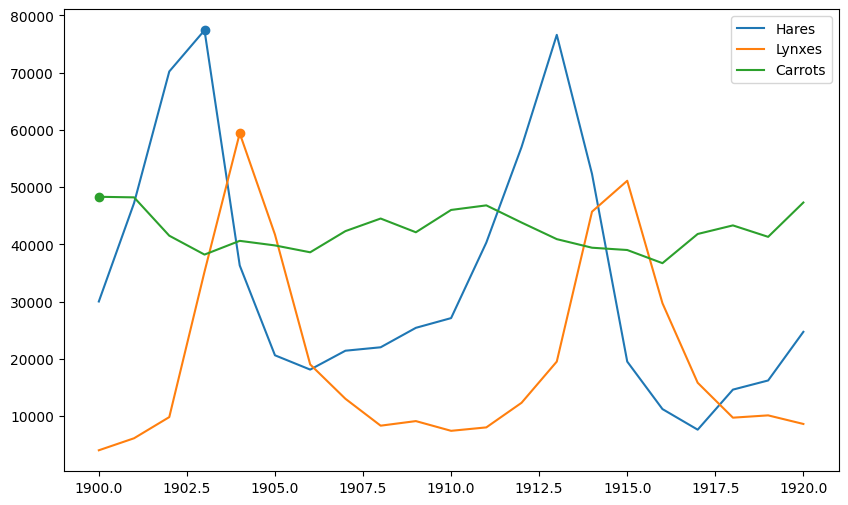

In [5]:
max_year_hares = years[np.argmax(hares)]
max_year_lynxes = years[np.argmax(lynxes)]
max_year_carrots = years[np.argmax(carrots)]

plt.figure(figsize=(10,6))
plt.plot(years, hares, label="Hares")
plt.plot(years, lynxes, label="Lynxes")
plt.plot(years, carrots, label="Carrots")

plt.scatter(max_year_hares, hares.max())
plt.scatter(max_year_lynxes, lynxes.max())
plt.scatter(max_year_carrots, carrots.max())

plt.legend()
plt.show()

- Assuming total population of hares and lynxes is 100%, plot stacked bar graph showing ratio of each specis for each year in the period.

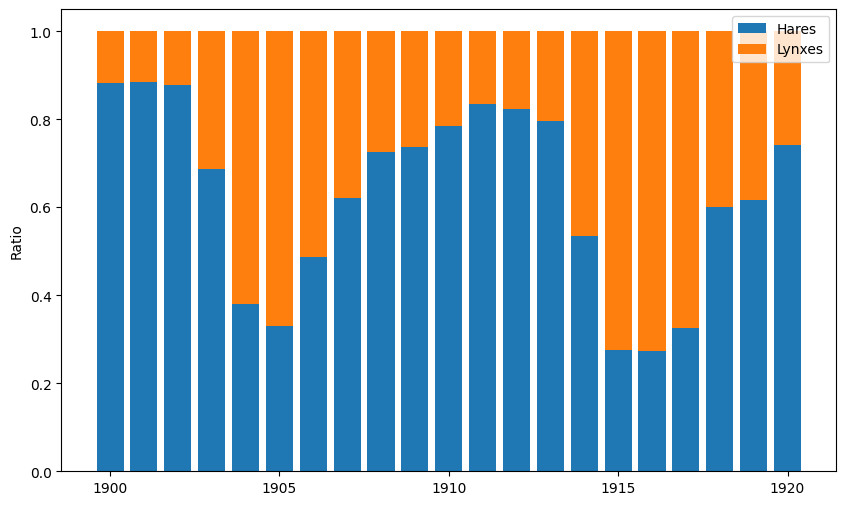

In [6]:
total = hares + lynxes
hare_ratio = hares / total
lynx_ratio = lynxes / total

plt.figure(figsize=(10,6))

plt.bar(years, hare_ratio, label="Hares")
plt.bar(years, lynx_ratio, bottom=hare_ratio, label="Lynxes")

plt.ylabel("Ratio")
plt.legend()
plt.show()

- Find the mean and std of the populations of each species. Plot the historgam of population for each species and show mean values with vertical line. Show each histogram in a separate plot. Arrange 3 plots in a row.

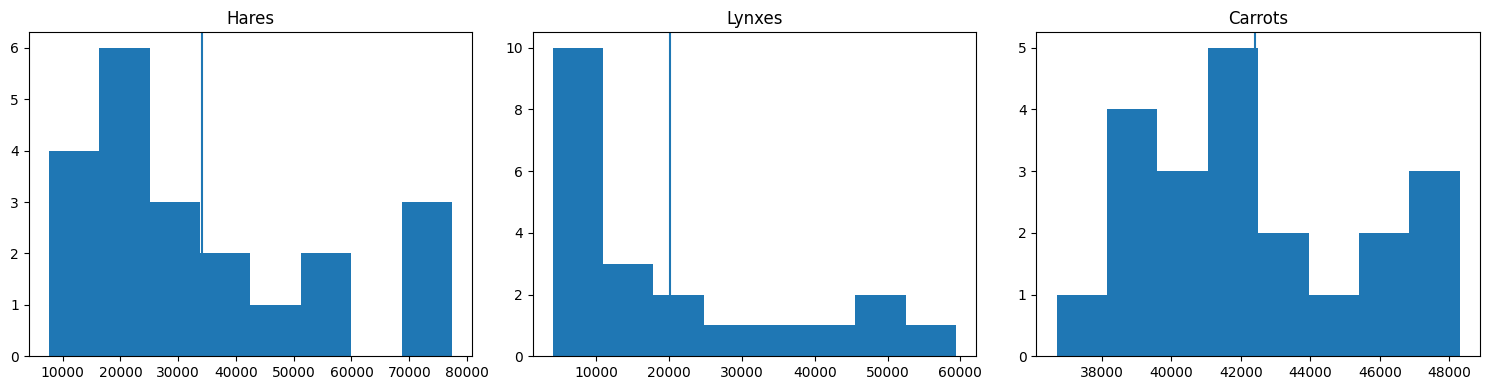

Means: [34080.95238095 20166.66666667 42400.        ]
Stds: [20897.90645809 16254.59153691  3322.50622558]


In [7]:
means = data[:,1:].mean(axis=0)
stds = data[:,1:].std(axis=0)

fig, axs = plt.subplots(1,3, figsize=(15,4))

species = [hares, lynxes, carrots]
names = ["Hares", "Lynxes", "Carrots"]

for ax, pop, name, mean in zip(axs, species, names, means):
    ax.hist(pop, bins=8)
    ax.axvline(mean)
    ax.set_title(name)

plt.tight_layout()
plt.show()

print("Means:", means)
print("Stds:", stds)

- Find which species (hares or lynxes) has the largest population for each year. Print the result as [H, H, L, H, ...]. Plot a pie chart showing the ratio of "H" and "L" values.

[np.str_('H'), np.str_('H'), np.str_('H'), np.str_('H'), np.str_('L'), np.str_('L'), np.str_('L'), np.str_('H'), np.str_('H'), np.str_('H'), np.str_('H'), np.str_('H'), np.str_('H'), np.str_('H'), np.str_('H'), np.str_('L'), np.str_('L'), np.str_('L'), np.str_('H'), np.str_('H'), np.str_('H')]


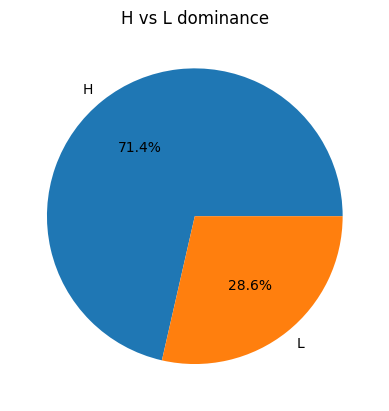

In [8]:
HL = np.where(hares > lynxes, "H", "L")
print(list(HL))

unique, counts = np.unique(HL, return_counts=True)

plt.pie(counts, labels=unique, autopct="%1.1f%%")
plt.title("H vs L dominance")
plt.show()

- Plot the change in the hare population and in the lynx population for each year. Find the correlation coefficient between the both time series.

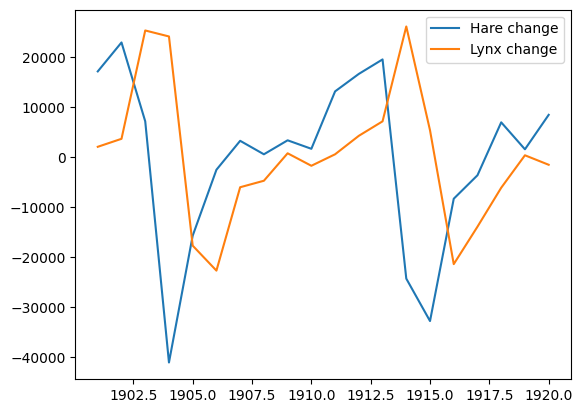

Correlation: -0.1780136594118296


In [9]:
hare_change = np.diff(hares)
lynx_change = np.diff(lynxes)

plt.plot(years[1:], hare_change, label="Hare change")
plt.plot(years[1:], lynx_change, label="Lynx change")
plt.legend()
plt.show()

corr = np.corrcoef(hare_change, lynx_change)[0,1]
print("Correlation:", corr)

- Using a scatter plot, show the population of hares vs lynxes by year (each point corresponds to a particular year, and the point coordinates correspond to the population of the two species in that year).

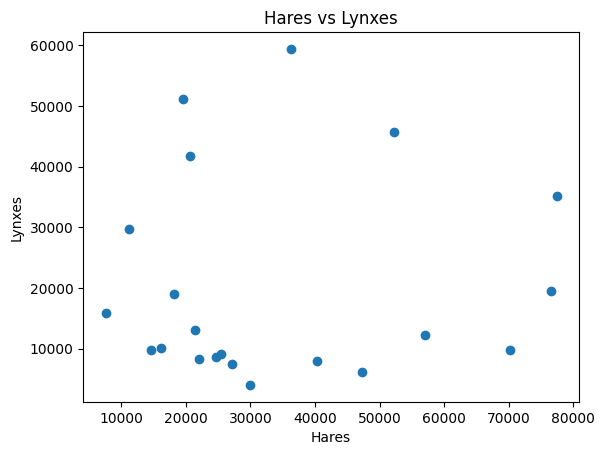

In [10]:
plt.scatter(hares, lynxes)
plt.xlabel("Hares")
plt.ylabel("Lynxes")
plt.title("Hares vs Lynxes")
plt.show()

- Assume the population of hares in 1920 is unknown. Suggest a way to estimate this value. Compare an estimated value
with the true value and print a ratio of the error to the true value.

In [11]:
from scipy.interpolate import interp1d

f_interp = interp1d(years[1:], hares[1:], kind="linear")
estimate = f_interp(1920)

true_value = hares[0]

error_ratio = abs(estimate - true_value) / true_value

print("Estimate:", estimate)
print("True:", true_value)
print("Relative error:", error_ratio)

Estimate: 24700.0
True: 30000.0
Relative error: 0.17666666666666667
